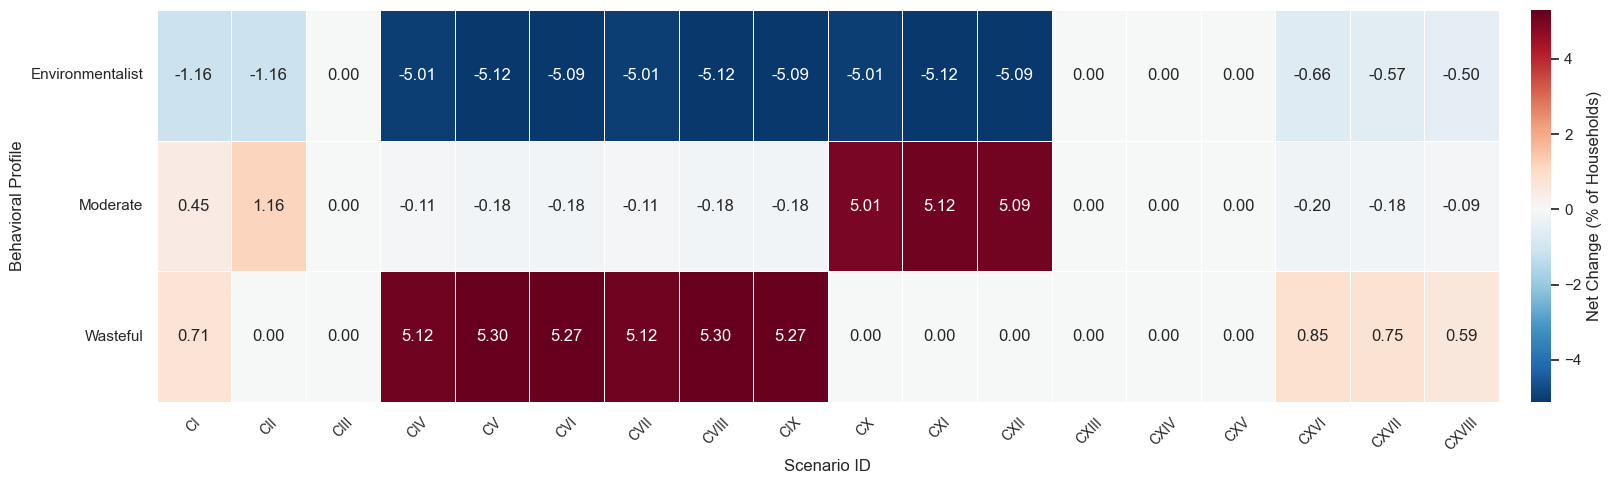

Success! Map saved with correct Roman numeral sort at: ../resultados/figure-net-behavioral-shift-heatmap-h-fig13.pdf


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Caminhos Padronizados
INPUT_FILE = '../resultados/comparativo_perfil_cenarios_qgis.csv'
OUTPUT_PDF = '../resultados/figure-net-behavioral-shift-heatmap-h-fig13.pdf'
OUTPUT_PNG = '../resultados/figure-net-behavioral-shift-heatmap-h-fig13.png'

def roman_to_int(s):
    """Converte algarismos romanos (I, V, X) para inteiros."""
    roman_map = {'I': 1, 'V': 5, 'X': 10}
    total = 0
    prev_value = 0
    for char in reversed(s):
        value = roman_map[char]
        if value < prev_value:
            total -= value
        else:
            total += value
        prev_value = value
    return total

def scenario_sort_key(scenario_name):
    """Extrai a parte romana após o 'C' e converte para inteiro para a ordenação."""
    # Remove o prefixo 'C' e converte o restante (ex: 'IX' -> 9)
    roman_part = scenario_name[1:]
    return roman_to_int(roman_part)

def generate_behavioral_impact_map_horizontal():
    if not os.path.exists(INPUT_FILE):
        print(f"Error: {INPUT_FILE} not found.")
        return

    # 1. Carga dos dados (Ajuste o separador conforme o arquivo real)
    df = pd.read_csv(INPUT_FILE, sep=',')
    
    # 2. Extração da Baseline e Ordenação Correta
    # Aplica a função de conversão romana na chave de ordenação
    unique_scenarios = sorted(df['NM_CENARIO'].unique(), key=scenario_sort_key)
    
    total_agents = len(df[df['NM_CENARIO'] == unique_scenarios[0]])
    initial_dist = df[df['NM_CENARIO'] == unique_scenarios[0]]['TP_COMPORTAMENTO'].value_counts()
    
    # 3. Processamento do impacto por cenário
    profiles = ['AMBIENTALISTA', 'MODERADO', 'PERDULARIO']
    impact_data = []

    for scenario in unique_scenarios:
        df_scen = df[df['NM_CENARIO'] == scenario]
        final_dist = df_scen['TP_NOVO_COMPORTAMENTO'].value_counts()
        
        row = {'Scenario': scenario}
        for p in profiles:
            net_change = ((final_dist.get(p, 0) - initial_dist.get(p, 0)) / total_agents) * 100
            row[p] = net_change
        impact_data.append(row)

    # 4. Transposição para Layout Horizontal
    impact_df = pd.DataFrame(impact_data).set_index('Scenario').T

    # 5. Plotagem Técnica (Elsevier Standard)
    plt.figure(figsize=(18, 5)) 
    sns.set_theme(style="white")
    
    # RdBu_r: Azul para redução e Vermelho para aumento
    ax = sns.heatmap(
        impact_df, 
        annot=True, 
        fmt=".2f", 
        cmap="RdBu_r", 
        center=0,
        linewidths=.5,
        cbar_kws={'label': 'Net Change (% of Households)', 'pad': 0.02}
    )
    
    #plt.title("Net Change in Consumption Profiles per Simulation Scenario\n(Comparison: Final State vs. Baseline)", 
    #          fontsize=14, fontweight='bold', pad=20)
    plt.ylabel("Behavioral Profile", fontsize=12)
    plt.xlabel("Scenario ID", fontsize=12)
    
    # Rótulos das colunas e linhas
    ax.set_yticklabels(['Environmentalist', 'Moderate', 'Wasteful'], rotation=0, fontsize=11)
    ax.set_xticklabels(unique_scenarios, rotation=45, fontsize=10)
    
    plt.tight_layout()
    
    # 6. Salvamento
    plt.savefig(OUTPUT_PDF, format='pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_PNG, format='png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Success! Map saved with correct Roman numeral sort at: {OUTPUT_PDF}")

if __name__ == "__main__":
    generate_behavioral_impact_map_horizontal()